
# Training Neural Networks

## The Goal of Training

A Neural Network starts with random weights. It knows nothing. "Training" is the process of adjusting these weights to minimize the error between the network's predictions and the actual targets.

This process has three main components:

1.  **Loss Function**: How we measure error.
2.  **Optimizer**: How we update weights.
3.  **Backpropagation**: How we calculate the updates.

## Loss Functions (The Scorecard)

The Loss Function (or Cost Function) calculates a single number representing "how bad" the model is. The goal is to reduce it enough to generalize well on unseen data.

| Problem Type       | Loss Function                | Formula                          | Intuition                                                                          |
|------------------ |---------------------------- |-------------------------------- |---------------------------------------------------------------------------------- |
| **Regression**     | **Mean Squared Error (MSE)** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Penalizes large errors heavily. Standard for predicting prices, temperatures, etc. |
| **Classification** | **Cross-Entropy (Log Loss)** | $-\sum y \log(\hat{y})$          | Penalizes confident wrong answers. Used when outputs are probabilities (0 to 1).   |

## Optimization: SGD and Mini-Batches

We use **Gradient Descent** to minimize the loss. However, calculating the gradient for the **entire** dataset at every step (Batch GD) is slow and memory-intensive.

**Stochastic Gradient Descent (SGD)** solves this by updating weights after seeing just **one** example (or a small "Mini-Batch" of examples).

-   **Pros**: Faster, adds noise that helps escape "Local Minima" (valleys that aren't the lowest point).
-   **Cons**: The path to the bottom is zigzaggy and noisy.

## Backpropagation Intuition (The Chain Rule)

How do we know which specific weight in Layer 1 caused the error in Layer 5? We use the **Chain Rule** of calculus.

1.  **Forward Pass**: Input data flows through the network to produce a prediction. Loss is calculated.
2.  **Backward Pass**: We calculate the gradient of the Loss with respect to the Output. Then we propagate this gradient **backwards** layer by layer.
    -   **"Hey Layer 4, you contributed X to the error. Adjust your weights."**
    -   **"Hey Layer 3, based on Layer 4's error, you contributed Y&#x2026;"**

## The Vanishing Gradient Problem

In deep networks (many layers), gradients are multiplied repeatedly during backpropagation. If we use activation functions like **Sigmoid** (which has a maximum derivative of 0.25), we multiply many small numbers together: $$0.25 \times 0.25 \times 0.25 \times \dots \approx 0$$

The gradient "vanishes" before it reaches the early layers. The input layers never learn, and the deep network fails.

**Mitigation**: ReLU helps (derivative is 1 for positive inputs), which improves gradient flow. In practice, combine this with good initialization, normalization, and residual connections.

## Practical Demonstration: Monitoring Training

We will train an MLP on the Digits dataset and visualize the **Loss Curve** to see learning in action.

### Load Data

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load Digits (10 classes)
digits = load_digits()
X, y = digits.data, digits.target

# Split first, then scale using training data only (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data Shape: {X_train.shape}")

Data Shape: (1437, 64)


### Training with SGD

We use `MLPClassifier` with `solver='sgd'`. We set `verbose=True` to print the loss at each step (iteration).

In [2]:
from sklearn.neural_network import MLPClassifier

# Simple MLP
# learning_rate_init controls the step size
mlp = MLPClassifier(hidden_layer_sizes=(64,), 
                    activation='relu', 
                    solver='sgd', 
                    learning_rate_init=0.01, 
                    max_iter=500, 
                    random_state=42)

mlp.fit(X_train, y_train)

print(f"Final Accuracy: {mlp.score(X_test, y_test):.2f}")

Final Accuracy: 0.98


### Visualizing the Loss Curve

The `loss_curve_` attribute stores the history of the loss. If this curve goes down, the network is learning.

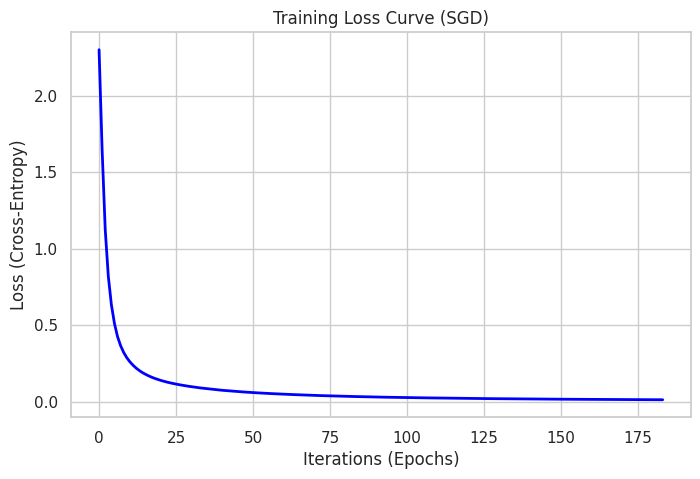

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='blue', linewidth=2)
plt.title("Training Loss Curve (SGD)")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss (Cross-Entropy)")
plt.grid(True)
plt.show()

**Observation**: The loss drops sharply at first and then flattens out. This is a healthy learning curve.

## Exercises

### The Learning Rate (Goldilocks Zone)

The **Learning Rate** is one of the most critical hyperparameters.

-   Train 3 models with rates: `0.0001` (Too Small), `0.01` (Reasonable), `10.0` (Too Large).
-   Plot their loss curves on the same graph.

/home/camarocico/Work/Teaching/DataScience/ml-workshop/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


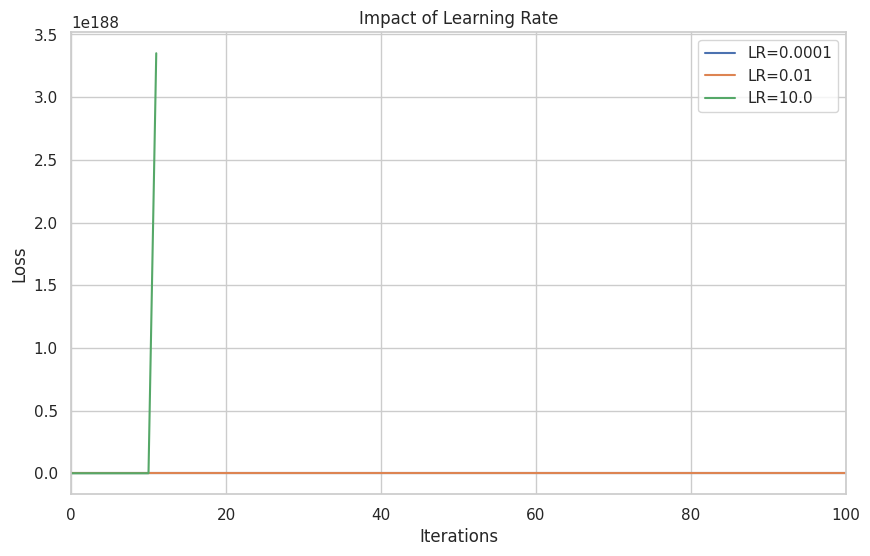

In [4]:
rates = [0.0001, 0.01, 10.0]
plt.figure(figsize=(10, 6))

for lr in rates:
      model = MLPClassifier(hidden_layer_sizes=(64,),
                            solver='sgd',
                            learning_rate_init=lr,
                            max_iter=1000,
                            random_state=42)
      model.fit(X_train, y_train)
      plt.plot(model.loss_curve_, label=f"LR={lr}")

plt.title("Impact of Learning Rate")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.xlim(0, 100)
#  plt.ylim(0, 5)
plt.legend()
plt.show()

**Result**:

-   Small rate: Loss goes down very slowly.
-   Large rate: Loss often oscillates or becomes unstable.
-   Reasonable rate: Usually smoother, faster descent.

### Vanishing Gradients (Sigmoid vs ReLU)

Train a **Deep Network** (5 layers) using Sigmoid vs. ReLU.

-   **Hypothesis**: The Sigmoid network will struggle to learn (Vanishing Gradient). The ReLU network will learn quickly.

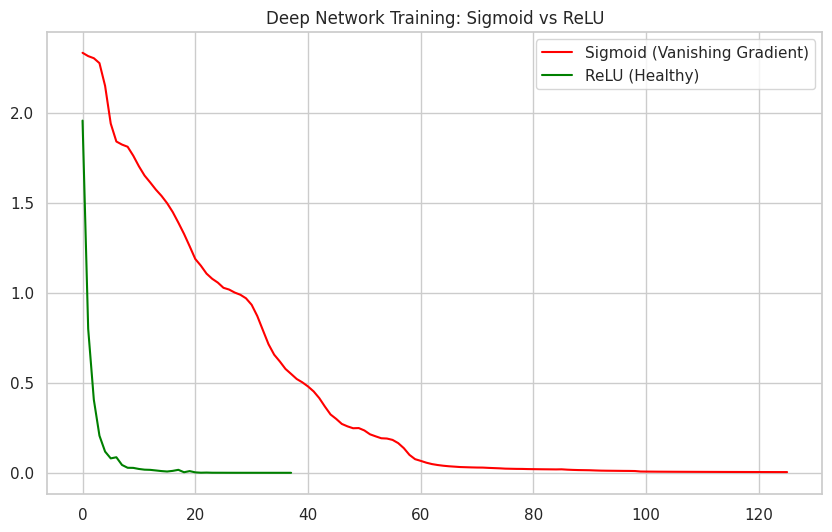

In [5]:
# Deep Architecture: 5 layers of 32 neurons
deep_layers = (32, 32, 32, 32, 32)

# Sigmoid Model
mlp_sig = MLPClassifier(hidden_layer_sizes=deep_layers,
                        activation='logistic', 
                        learning_rate_init=0.01,
                        max_iter=200,
                        random_state=42)
mlp_sig.fit(X_train, y_train)

# ReLU Model
mlp_relu = MLPClassifier(hidden_layer_sizes=deep_layers,
                         activation='relu', 
                         learning_rate_init=0.01,
                         max_iter=200,
                         random_state=42)
mlp_relu.fit(X_train, y_train)

# Compare Curves
plt.figure(figsize=(10, 6))
plt.plot(mlp_sig.loss_curve_, label="Sigmoid (Vanishing Gradient)", color='red')
plt.plot(mlp_relu.loss_curve_, label="ReLU (Healthy)", color='green')
plt.title("Deep Network Training: Sigmoid vs ReLU")
plt.legend()
plt.show()

## Summary

1.  **Loss Function**: Cross-Entropy for classification, MSE for regression.
2.  **SGD**: Updates weights using small batches to be faster and escape traps.
3.  **Backprop**: Passes the "blame" (error) backwards to update weights.
4.  **Vanishing Gradient**: Sigmoid can struggle in deep networks; **ReLU** helps mitigate this by improving gradient flow.